In [1]:
%matplotlib widget
# Boilerplate import code for all libraries
# Changes to the precision require re-loading the kernel and need to be done before any op uses them.
import sphWarpCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double

import sphWarpCore as sph
from sphWarpCore.type_config import *
print(get_type_config()) # confirms active settings

# Initialize warp at this point
import warp as wp; wp.init()

import os
import torch
if torch.cuda.is_available(): # set the TORCH_CUDA_ARCH_LIST environment variable to the compute capability of the GPU for faster compiles
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

# final import blocks that are generic
import matplotlib.pyplot as plt
from torch.profiler import profile, record_function, ProfilerActivity
import numpy as np
import math
import shlex    
import subprocess
import shutil

# custom SPH libraries
from integrators.integration import *
from sphWarpCore import *

# This library
from warpSPH import *
from warpSPH.modules.timestep.compressible import computeTimestep

# The case utilities that contain all the case setup functions for the various test cases
from warpSPH.caseUtils import *

{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:
nx = 128
dim = 2
L = 2
n_h = 4

rho0 = 1

octaves = 1
lacunarity = 2
persistence = 0.5
baseFrequency = 1
tileable = True
kind = 'perlin'
seed = 45906734
obstacle = False


extraData = {
    'nx': nx,
    'dim': dim,
    'L': L,
    'n_h': n_h,

    'rho0': rho0,

    'octaves': octaves,
    'lacunarity': lacunarity,
    'persistence': persistence,
    'baseFrequency': baseFrequency,
    'tileable': tileable,
    'kind': kind,
    'seed': seed,
    'obstacle': obstacle
}

In [3]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()



dx = L / (nx)
band = 5

domain = buildDomainDescription(L + dx * (band) * 2, dim, True, device, dtype)
interiorDomain = buildDomainDescription(L, dim, False, device, dtype)

config, integrator = buildConfig(
    domain = domain,
    dim = dim,
    kernel = KernelFunctions.Wendland4,
    targetNeighbors = n_h_to_nH(4, dim),
    supportMode = SupportScheme.KernelMeanSymmetric,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = None,
    adaptiveDt = True,
    cflFactor=0.3,
)
config.nx = nx + band * 2
config.dx = (interiorDomain.max[0] - interiorDomain.min[0]) / (nx + 1)

config.minDt = 1e-8
# config.dx = L / (nx * 2)

scheme = WeaklyCompressibleSPHScheme.deltaSPH
SimulationSystem, SimulationState, SimulationConfig, SimulationUpdate, fn, export_fn, import_fn = buildScheme(scheme)


schemeConfig = SimulationConfig()


schemeConfig.viscositySwitchParams.scheme = ViscositySwitch.NoneSwitch
schemeConfig.adaptiveSupportScheme = AdaptiveSupportScheme.Owen
schemeConfig.adaptiveSupportCorrections = False


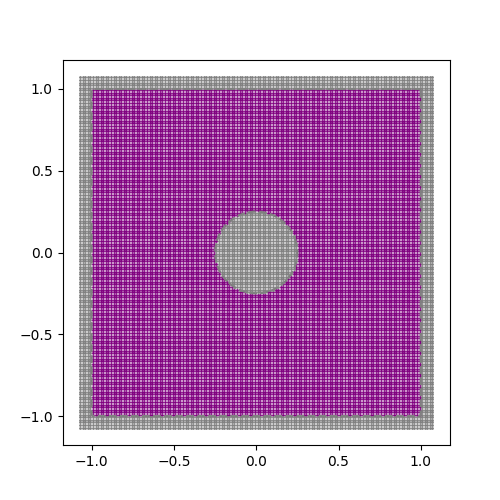

In [4]:

# domain = buildDomainDescription(l = L + dx * (band) * 2, dim = dim, periodic = True, device = device, dtype = dtype)
# interiorDomain = buildDomainDescription(l = L, dim = dim, periodic = False, device = device, dtype = dtype)

fluid_sdf = lambda x: sampleDomainSDF(x, domain, invert = True)
domain_sdf = lambda x: sampleDomainSDF(x, interiorDomain, invert = False)
obstacle_sdf = lambda points: sampleSDF(points, lambda x: getSDF('circle')['function'](x, torch.tensor(1/4).to(points.device)), invert = False)


regions = []

regions.append(buildRegion(config, schemeConfig, fluid_sdf, RegionType.Fluid, initialConditions = {}))
regions.append(buildRegion(config, schemeConfig, domain_sdf, RegionType.Boundary, initialConditions = {}, kind = BCType.freeSlip))
regions.append(buildRegion(config, schemeConfig, obstacle_sdf, RegionType.Boundary, initialConditions = {}, kind = BCType.freeSlip))



for region in regions:
    region = filterRegion(region, regions)

    


fig, axis = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)
    
plotRegions(regions, axis[0,0], plotFluid = True, plotParticles = True)


compressibleSystem = initializeWeaklyCompressibleSimulation(regions, config, schemeConfig, SimulationSystem, SimulationState, verbose = True)

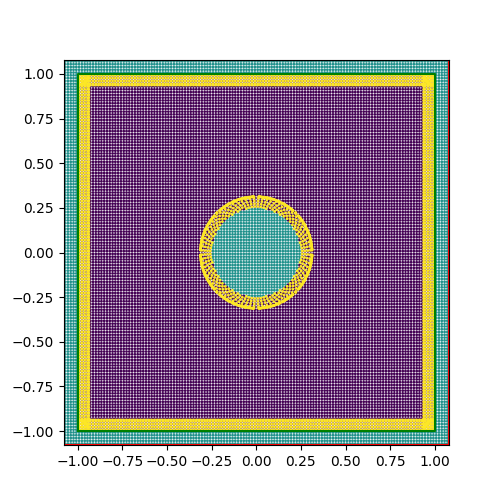

In [5]:
fig, axis = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)

axis[0,0].scatter(compressibleSystem.state.positions[:,0].cpu().numpy(), compressibleSystem.state.positions[:,1].cpu().numpy(), s = 1, c = compressibleSystem.state.kinds.cpu().numpy(), cmap = 'viridis')

axis[0,0].axhline(domain.min[1].cpu().numpy(), color = 'r')
axis[0,0].axhline(domain.max[1].cpu().numpy(), color = 'r')
axis[0,0].axvline(domain.min[0].cpu().numpy(), color = 'r')
axis[0,0].axvline(domain.max[0].cpu().numpy(), color = 'r')

axis[0,0].plot([interiorDomain.min[0].cpu().numpy(), interiorDomain.max[0].cpu().numpy(), interiorDomain.max[0].cpu().numpy(), interiorDomain.min[0].cpu().numpy(), interiorDomain.min[0].cpu().numpy()], [interiorDomain.min[1].cpu().numpy(), interiorDomain.min[1].cpu().numpy(), interiorDomain.max[1].cpu().numpy(), interiorDomain.max[1].cpu().numpy(), interiorDomain.min[1].cpu().numpy()], color = 'g')

axis[0,0].set_xlim(domain.min[0].cpu().numpy(), domain.max[0].cpu().numpy())
axis[0,0].set_ylim(domain.min[1].cpu().numpy(), domain.max[1].cpu().numpy())
axis[0,0].set_aspect('equal', adjustable='box')

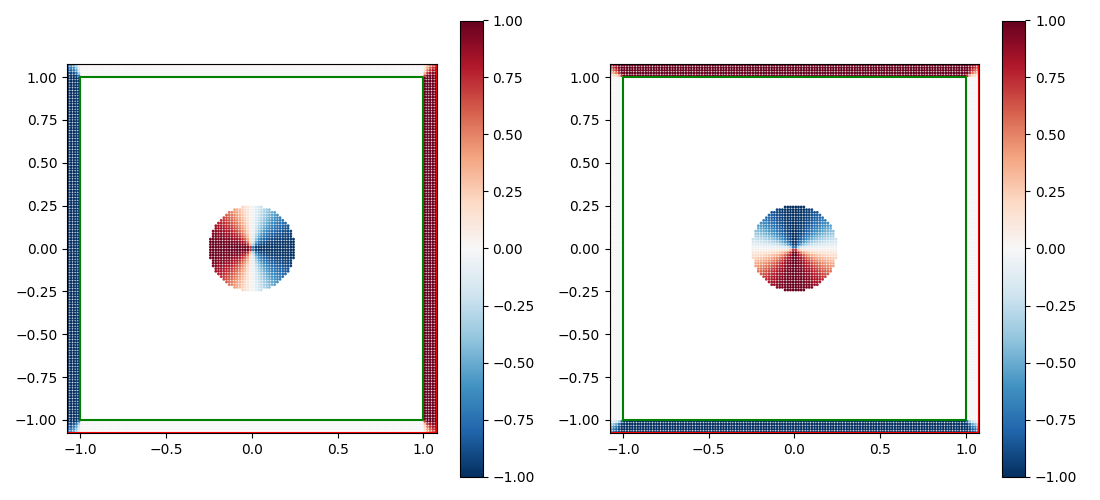

In [6]:
fig, axis = plt.subplots(1, 2, figsize=(11, 5), squeeze=False)

fluidMask = compressibleSystem.state.kinds == 0
boundaryMask = compressibleSystem.state.kinds == 1
ghostMask = compressibleSystem.state.kinds == 2

q = torch.nn.functional.normalize(compressibleSystem.state.ghostOffsets, dim = -1)
mask = boundaryMask

qMasked = q[mask, 0]

sc = axis[0,0].scatter(compressibleSystem.state.positions[mask,0].cpu().numpy(), compressibleSystem.state.positions[mask,1].cpu().numpy(), s = 1, c = qMasked.cpu().numpy(), cmap = 'RdBu_r')
fig.colorbar(sc, ax = axis[0,0])

q2Masked = q[mask, 1]
sc2 = axis[0,1].scatter(compressibleSystem.state.positions[mask,0].cpu().numpy(), compressibleSystem.state.positions[mask,1].cpu().numpy(), s = 1, c = q2Masked.cpu().numpy(), cmap = 'RdBu_r')
fig.colorbar(sc2, ax = axis[0,1])

for ax in axis.flatten():
    ax.axhline(domain.min[1].cpu().numpy(), color = 'r')
    ax.axhline(domain.max[1].cpu().numpy(), color = 'r')
    ax.axvline(domain.min[0].cpu().numpy(), color = 'r')
    ax.axvline(domain.max[0].cpu().numpy(), color = 'r')

    ax.plot([interiorDomain.min[0].cpu().numpy(), interiorDomain.max[0].cpu().numpy(), interiorDomain.max[0].cpu().numpy(), interiorDomain.min[0].cpu().numpy(), interiorDomain.min[0].cpu().numpy()], [interiorDomain.min[1].cpu().numpy(), interiorDomain.min[1].cpu().numpy(), interiorDomain.max[1].cpu().numpy(), interiorDomain.max[1].cpu().numpy(), interiorDomain.min[1].cpu().numpy()], color = 'g')

    ax.set_xlim(domain.min[0].cpu().numpy(), domain.max[0].cpu().numpy())
    ax.set_ylim(domain.min[1].cpu().numpy(), domain.max[1].cpu().numpy())
    ax.set_aspect('equal', adjustable='box')

fig.tight_layout()

In [7]:
nu_inviscid = alphaToNu(schemeConfig.diffusionParams.inviscidAlpha, schemeConfig.fluid.fixedSoundSpeed, compressibleSystem.state.supports.mean().cpu().item(), config.dim)
alpha_effective = nuToAlpha(schemeConfig.diffusionParams.viscidNu, schemeConfig.fluid.fixedSoundSpeed, compressibleSystem.state.supports.mean().cpu().item(), config.dim)
print(f"nu_inviscid: {nu_inviscid}, alpha_effective: {alpha_effective}")

nu_inviscid: 0.00078125, alpha_effective: 0.0128


In [8]:
# compressibleSystem.state.positions = shuffleParticles(compressibleSystem.state, config, schemeConfig, 128, jitterAmount = 0.5)

In [9]:


velocities = sampleDivergenceFreeNoise(compressibleSystem.state, domain, config, schemeConfig, nx * 2, 
                                    octaves = octaves, lacunarity = lacunarity, persistence = persistence, baseFrequency = baseFrequency, tileable = tileable, kind = kind, seed = seed)
compressibleSystem.state.velocities[:] = velocities

Module sphWarpCore.radiusSearch.wp_compactHash e67fccd load on device 'cuda:0' took 2.18 ms  (cached)
Module sphWarpCore.operations.wp_density 681e434 load on device 'cuda:0' took 2.32 ms  (cached)
Module sphWarpCore.operations.wp_gradient 77e4101 load on device 'cuda:0' took 6.28 ms  (cached)


Module sphWarpCore.operations_grid.wp_interpolate_grid d2796eb load on device 'cuda:0' took 3.01 ms  (cached)
Module sphWarpCore.operations_grid.wp_interpolate_grid 7168a07 load on device 'cuda:0' took 3.02 ms  (cached)


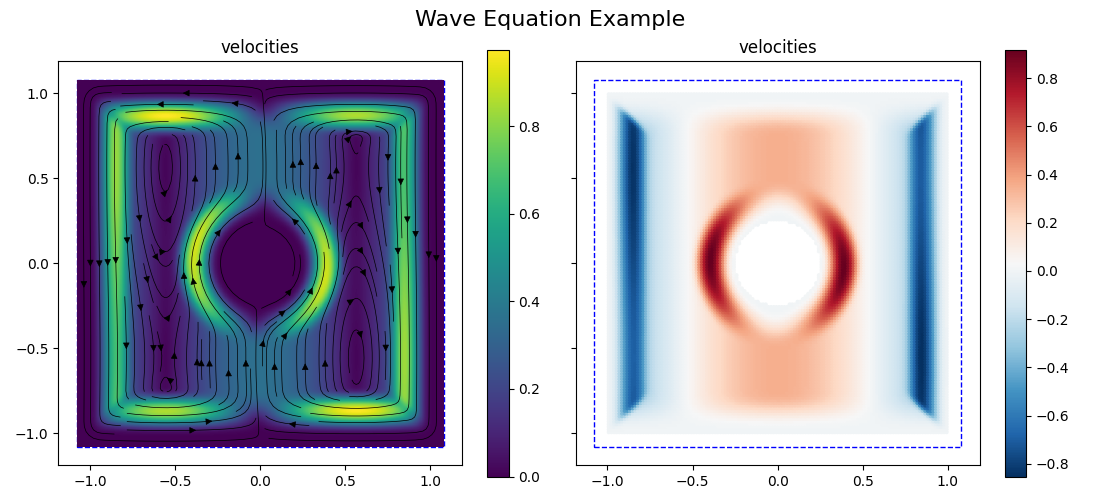

In [10]:
runningState = compressibleSystem.initializeNewState()

from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, Mapping, DivergingColorMap,VisualizeOptions
markerSize = 4
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B": runningState.state.velocities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.L2,
            plotTitle = "velocities",
            gridVisualization = GridVisualization(
                resolution = 1024,
                streamLines = True
            ),
            # boundaryVisualization = VisualizeOptions.Visualize,
            # # vMin=1e-10,
            # stream
        ),
        "B": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "velocities",
            mapping = Mapping.y,
            # plottingOperation = OperationProperties(
            #     operation = WarpOperation.Curl,
            #     kernel = config.kernel,
            #     supportMode = SupportScheme.Gather, # cullen switch E.1 in the CRK paper uses gather for density estimation
            # ),
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (11,5),
    backend='matplotlib',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

# if args.exportImages:
#     plotter.export(f'output/{folderName}/frame_00000.png', dpi = args.figureDpi)


# imagePath = f'{exportPath}/images'
# os.makedirs(imagePath, exist_ok = True)
# plotter.export(f'{imagePath}/frame_00000.png', dpi = 300)

Module sphWarpCore.operations_grid.wp_density_grid d6cfc50 load on device 'cuda:0' took 2.30 ms  (cached)
Fluid particles: 15572, Boundary particles: 3472, Ghost particles: 3472


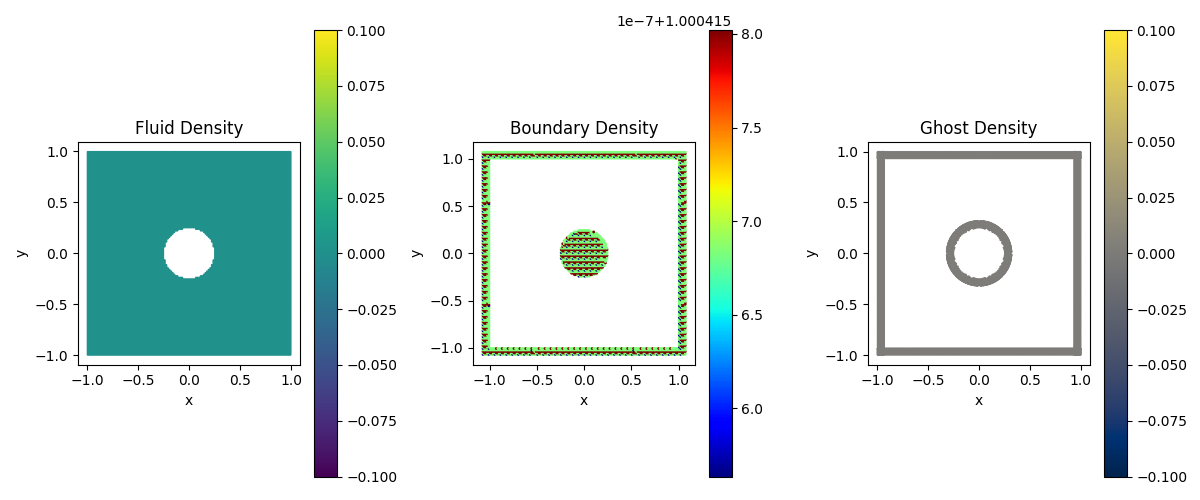

In [11]:
density = warpOperation(
        runningState.state,
        OperationProperties(
            kernel = config.kernel,
            operation = WarpOperation.Density,
            supportMode = SupportScheme.Gather, # cullen switch E.1 in the CRK paper uses gather for density estimation
            # operationMode = OperationDirection.FluidToFluid,
            # operationMode = OperationDirection.FluidToBoundary,
            # operationMode = OperationDirection.BoundaryToFluid,
            # operationMode = OperationDirection.BoundaryToBoundary,
            # operationMode = OperationDirection.FluidToGhost,
            # operationMode = OperationDirection.BoundaryToGhost,
            # operationMode = OperationDirection.AllToGhost,
            operationMode = OperationDirection.AllToBoundary,
        ),
        domain = config.domain,
        adjacency = None,
    )

fig, axis = plt.subplots(1, 3, figsize=(12, 5), squeeze=False)

pos = runningState.state.positions.cpu().numpy()
kinds = runningState.state.kinds.cpu().numpy()
fluid = kinds == 0
boundary = kinds == 1
ghost = kinds == 2

print(f"Fluid particles: {fluid.sum()}, Boundary particles: {boundary.sum()}, Ghost particles: {ghost.sum()}")

q = density.cpu().numpy()

markerSize = 1

sc = axis[0,0].scatter(pos[fluid,0], pos[fluid,1], c = q[fluid], s = markerSize, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,0])
sc = axis[0,1].scatter(pos[boundary,0], pos[boundary,1], c = q[boundary], s = markerSize, cmap = 'jet')
fig.colorbar(sc, ax = axis[0,1])
sc = axis[0,2].scatter(pos[ghost,0], pos[ghost,1], c = q[ghost], s = markerSize, cmap = 'cividis')
fig.colorbar(sc, ax = axis[0,2])

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

axis[0,0].set_title('Fluid Density')
axis[0,1].set_title('Boundary Density')
axis[0,2].set_title('Ghost Density')

fig.tight_layout()

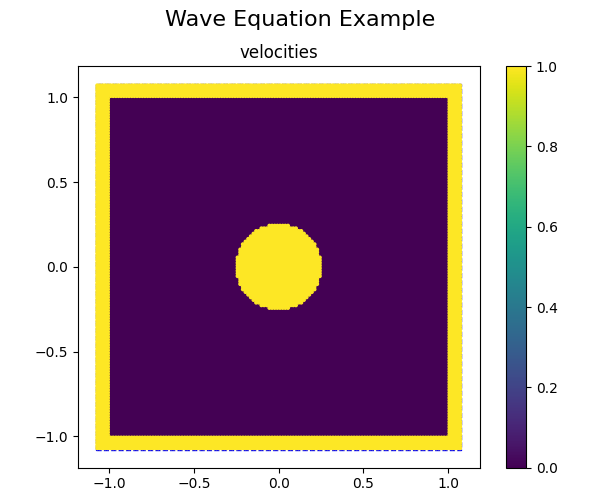

In [12]:
runningState = compressibleSystem.initializeNewState()

from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, Mapping, DivergingColorMap,VisualizeOptions
markerSize = 4
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": density,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.x,
            plotTitle = "velocities",
            # gridVisualization = GridVisualization(
            #     resolution = 1024,
            #     # streamLines = True
            # ),
            boundaryVisualization = VisualizeOptions.Visualize,
            # # vMin=1e-10,
            # stream
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'A',
    figsize= (6,5),
    backend='matplotlib',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

# if args.exportImages:
#     plotter.export(f'output/{folderName}/frame_00000.png', dpi = args.figureDpi)


# imagePath = f'{exportPath}/images'
# os.makedirs(imagePath, exist_ok = True)
# plotter.export(f'{imagePath}/frame_00000.png', dpi = 300)

In [13]:

adjacency = buildVerletList(
    runningState.state, 
    config.domain, verletScale = 1.0, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = None,
    verbose = False)

Module compressibleSPH.modules.liu.wp_mat 98e5348 load on device 'cuda:0' took 2.79 ms  (cached)
Fluid particles: 15572, Boundary particles: 3472, Ghost particles: 3472


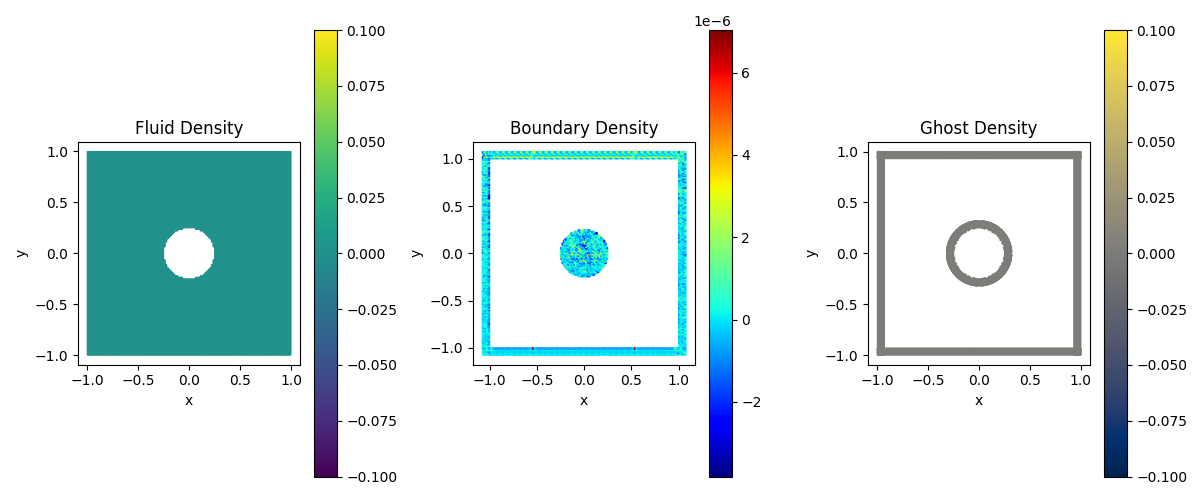

In [14]:
runningState.state.densities = 2 + runningState.state.positions[:,1]

density = computeMdbcDensity(runningState.state, config, schemeConfig, adjacency)

fig, axis = plt.subplots(1, 3, figsize=(12, 5), squeeze=False)

pos = runningState.state.positions.cpu().numpy()
kinds = runningState.state.kinds.cpu().numpy()
fluid = kinds == 0
boundary = kinds == 1
ghost = kinds == 2

print(f"Fluid particles: {fluid.sum()}, Boundary particles: {boundary.sum()}, Ghost particles: {ghost.sum()}")

q = density.cpu().numpy() - (2 + pos[:,1])

markerSize = 1

sc = axis[0,0].scatter(pos[fluid,0], pos[fluid,1], c = q[fluid], s = markerSize, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,0])
sc = axis[0,1].scatter(pos[boundary,0], pos[boundary,1], c = q[boundary], s = markerSize, cmap = 'jet')
fig.colorbar(sc, ax = axis[0,1])
sc = axis[0,2].scatter(pos[ghost,0], pos[ghost,1], c = q[ghost], s = markerSize, cmap = 'cividis')
fig.colorbar(sc, ax = axis[0,2])

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

axis[0,0].set_title('Fluid Density')
axis[0,1].set_title('Boundary Density')
axis[0,2].set_title('Ghost Density')

fig.tight_layout()


In [15]:
from warpSPH.modules.mdbc.velocity import *

In [16]:
runningState.state.densities[:] = 1.0

runningState.state.velocities[:,0] = runningState.state.positions[:,0]
runningState.state.velocities[:,1] = runningState.state.positions[:,1]

runningState.state.velocities[:,0] = 1
runningState.state.velocities[:,1] = 0

# runningState.state.velocities[runningState.state.kinds != 0,:] = 0.0

In [17]:
# config.regions[2].type = BCType.extended

In [18]:
from typing import Any, Optional, Union

def freeSlip(currentState: Any, config: SimulationConfig, schemeConfig: WeaklyCompressibleSPHConfig, adjacency: Optional[Union[AdjacencyList, CompactHashMap]]) -> torch.Tensor:
    """
    Computes the free-slip boundary condition for ghost particles based on the velocities of fluid particles.
    """
    # Interpolate fluid velocities to ghost particles
    qVel = warpOperation(
        currentState,
        OperationProperties(
            kernel = config.kernel,
            operation = WarpOperation.Interpolate,
            supportMode = SupportScheme.Gather,
            operationMode = OperationDirection.FluidToGhost
        ),
        domain = config.domain,
        adjacency = adjacency,
        queryValues = currentState.velocities,
    )
    
    # Compute Shepard values for normalization
    shepValue = warpOperation(
        currentState,
        OperationProperties(
            kernel = config.kernel,
            operation = WarpOperation.Interpolate,
            supportMode = SupportScheme.Gather,
            operationMode = OperationDirection.FluidToGhost
        ),
        domain = config.domain,
        adjacency = adjacency,
        queryValues = torch.ones_like(currentState.densities),
    )

    # Normalize interpolated velocities
    qVel = qVel / (shepValue.view(-1,1) + 1e-7)

    # Compute the free-slip condition: u_g = u_f - 2 * (u_f . n_b) * n_b
    bodyVelocity = currentState.velocities
    bIndices = currentState.ghostIndices[currentState.kinds == 2]
    
    r_ib = torch.linalg.norm(currentState.ghostOffsets, dim=-1)
    n_b = currentState.ghostOffsets / (r_ib.view(-1,1) + 1e-7)

    projected_vels = qVel - torch.einsum('nd, nd -> n', qVel, n_b).view(-1,1) * n_b
    projected_vels[bIndices,:] = projected_vels[currentState.kinds == 2,:]


    return projected_vels


In [19]:
velocities = freeSlip(
    runningState.state,
    config, schemeConfig,
    adjacency
)

velocities[runningState.state.kinds == 0,:] = runningState.state.velocities[runningState.state.kinds == 0,:]

Module sphWarpCore.operations.wp_interpolate f8df5f2 load on device 'cuda:0' took 1.79 ms  (cached)
Module sphWarpCore.operations.wp_interpolate ae0025d load on device 'cuda:0' took 2.92 ms  (cached)


In [20]:
v0 = velocities[torch.logical_and(runningState.state.kinds == 1, runningState.state.materials == 0), :]
v1 = velocities[torch.logical_and(runningState.state.kinds == 1, runningState.state.materials == 1), :]

print(f"v0: min: [{v0[:,0].min().item()}, {v0[:,1].min().item()}], max: [{v0[:,0].max().item()}, {v0[:,1].max().item()}]")
print(f"v1: min: [{v1[:,0].min().item()}, {v1[:,1].min().item()}], max: [{v1[:,0].max().item()}, {v1[:,1].max().item()}]")


v0: min: [1.5497207641601562e-06, -0.4999992549419403], max: [0.9999998807907104, 0.4999992549419403]
v1: min: [0.0010523200035095215, -0.4999997019767761], max: [0.9989603161811829, 0.4999997019767761]


Fluid particles: 15572, Boundary particles: 3472, Ghost particles: 3472


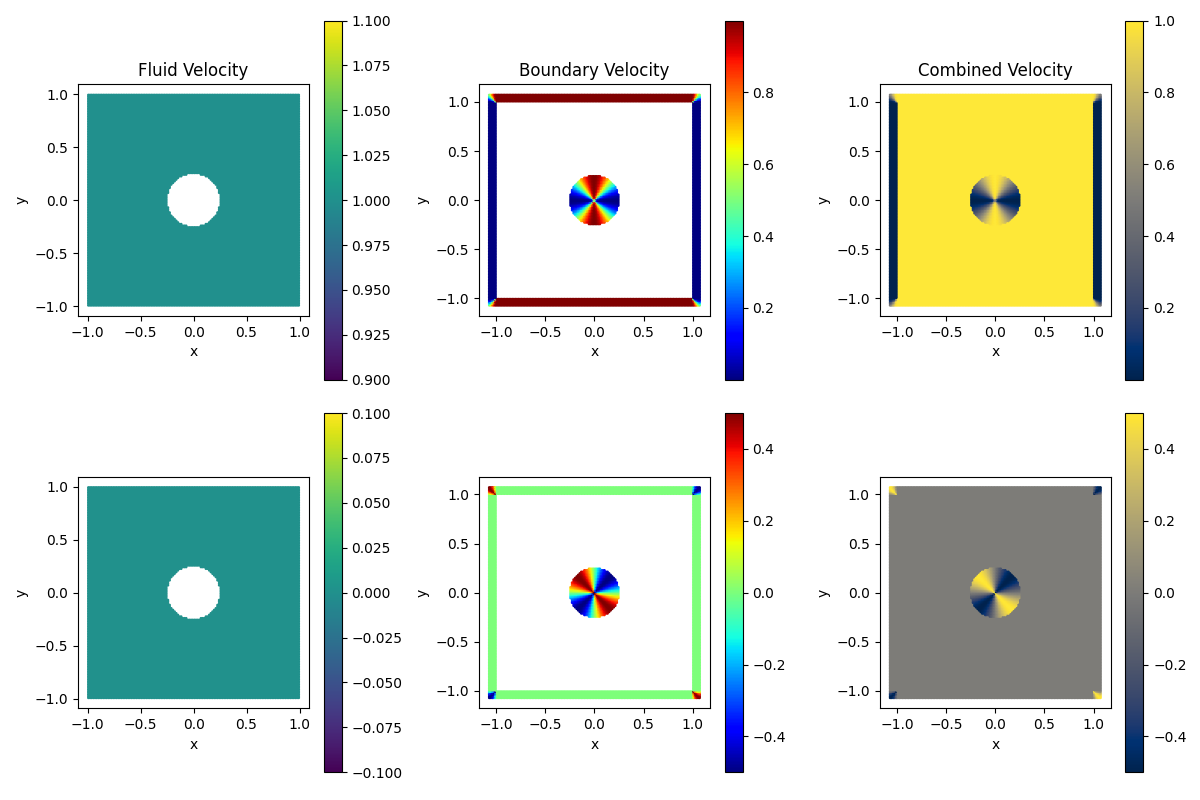

In [21]:


fig, axis = plt.subplots(2, 3, figsize=(12, 8), squeeze=False)
markerSize = 1

pos = runningState.state.positions.cpu().numpy()
kinds = runningState.state.kinds.cpu().numpy()
fluid = kinds == 0
boundary = kinds == 1
ghost = kinds == 2

print(f"Fluid particles: {fluid.sum()}, Boundary particles: {boundary.sum()}, Ghost particles: {ghost.sum()}")

q = velocities[:,0]#- runningState.state.velocities[:,0]
q = q.cpu().numpy()

sc = axis[0,0].scatter(pos[fluid,0], pos[fluid,1], c = q[fluid], s = markerSize, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,0])
sc = axis[0,1].scatter(pos[boundary,0], pos[boundary,1], c = q[boundary], s = markerSize, cmap = 'jet')
fig.colorbar(sc, ax = axis[0,1])
sc = axis[0,2].scatter(pos[np.logical_or(fluid, boundary),0], pos[np.logical_or(fluid, boundary),1], c = q[np.logical_or(fluid, boundary)], s = markerSize, cmap = 'cividis')
fig.colorbar(sc, ax = axis[0,2])
# sc = axis[0,2].scatter(pos[ghost,0], pos[ghost,1], c = q[ghost], s = markerSize, cmap = 'cividis')
# fig.colorbar(sc, ax = axis[0,2])

q = velocities[:,1] #- runningState.state.velocities[:,1]
q = q.cpu().numpy()

sc = axis[1,0].scatter(pos[fluid,0], pos[fluid,1], c = q[fluid], s = markerSize, cmap = 'viridis')
fig.colorbar(sc, ax = axis[1,0])
sc = axis[1,1].scatter(pos[boundary,0], pos[boundary,1], c = q[boundary], s = markerSize, cmap = 'jet')
fig.colorbar(sc, ax = axis[1,1])
sc = axis[1,2].scatter(pos[np.logical_or(fluid, boundary),0], pos[np.logical_or(fluid, boundary),1], c = q[np.logical_or(fluid, boundary)], s = markerSize, cmap = 'cividis')
fig.colorbar(sc, ax = axis[1,2])
# sc = axis[1,2].scatter(pos[ghost,0], pos[ghost,1], c = q[ghost], s = markerSize, cmap = 'cividis')
# fig.colorbar(sc, ax = axis[1,2])


for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

axis[0,0].set_title('Fluid Velocity')
axis[0,1].set_title('Boundary Velocity')
axis[0,2].set_title('Combined Velocity')

fig.tight_layout()


In [22]:
q = torch.linalg.norm(runningState.state.ghostOffsets / config.dx, dim = -1)[ghost]
print(f"Ghost offsets: min={q.min().item()}, max={q.max().item()}, mean={q.mean().item()}, std={q.std().item()}")

Ghost offsets: min=0.09462067484855652, max=19.443618774414062, mean=5.813572883605957, std=3.6614928245544434


In [23]:
# from warpSPH.modules.mdbc.wp_nopenshift import computeMdbcNoPenShiftWarp

nopenshift = computeMdbcNoPenShift(runningState.state, config, schemeConfig, adjacency)

Module compressibleSPH.modules.mdbc.wp_nopenshift c46d02f load on device 'cuda:0' took 4.42 ms  (cached)


In [24]:
nopenshift.min(), nopenshift.max(), nopenshift.mean(), nopenshift.std()

(tensor(0., device='cuda:0'),
 tensor(0., device='cuda:0'),
 tensor(0., device='cuda:0'),
 tensor(0., device='cuda:0'))

In [25]:
runningState = compressibleSystem.initializeNewState()
from warpSPH.modules.timestep.weaklyCompressible import computeTimestep

config.dt = computeTimestep(
    system = compressibleSystem,
    config = config,
    compParams = schemeConfig,
    dt = 1e-4,
    systemUpdate = None,
)
print(config.dt)

tensor(0.0005, device='cuda:0')


In [26]:

caseName = 'randomVelocityFieldBoundedDiffBCOtherDir'
exportPath = prepExport(f'{caseName}', config, schemeConfig, scheme, export_fn)
exportSimulationSystem(exportPath, 'initialState', scheme, compressibleSystem, exportAdjacency = False, stages = None, exportStagesAdjacency = False, extraData = dict({
    'frame_num': 0,
}, **extraData))

In [27]:
from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, Mapping, DivergingColorMap, CyclicColorMap
markerSize = 8
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B": runningState.state.UIDs,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            boundaryVisualization = VisualizeOptions.Visualize,
            mapping = Mapping.L2Norm,
            plotTitle = "velocities",
            # gridVisualization = GridVisualization(
            #     resolution = 1024,
            # ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = CyclicColorMap.twilight,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 1.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "UIDs",
            boundaryVisualization = VisualizeOptions.Hide,
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (11,5),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

imagePath = f'{exportPath}/images'
os.makedirs(imagePath, exist_ok = True)
plotter.export(f'{imagePath}/frame_00000.png', dpi = 300)


RFBOutputContext()

In [28]:
runningState = compressibleSystem.initializeNewState()
ke = torch.sum(0.5 * runningState.state.densities * torch.sum(runningState.state.velocities**2, dim=1)) / torch.sum(runningState.state.densities)

schemeConfig.diffusionParams.inviscid = False
schemeConfig.diffusionParams.nu = 0.01
# schemeConfig.shiftProperties.active = False
schemeConfig.fluid.eosType = EquationOfState.stiffTait

In [29]:

t_limit = 10.0
nSteps = int(t_limit / config.dt)

runningState = compressibleSystem.initializeNewState()

kes = []
priorStep = None
for i in (tq := tqdm(range(nSteps), leave = False)):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,  
        config = config,
        schemeConfig = schemeConfig,
        verbose = False,
        priorStep = priorStep
    )
    kes.append(torch.sum(0.5 * result.state.state.masses * torch.sum(result.state.state.velocities**2, dim=1)))
    # print('max_vel:', torch.linalg.norm(result.state.state.velocities, dim = -1).max())
    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)

    runningState = result.state

    if i % 10 == 0 and i > 0:
        plotter.updateQuantities(
            {
                "A": runningState.state.velocities,
                "B": runningState.state.UIDs,
            },
            newParticleState = runningState.state,
        )
        plotter.export(f'{imagePath}/frame_{i:05d}.png', dpi = 300)
        
    maxVel = torch.linalg.norm(runningState.state.velocities, dim = -1).max()
    tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{t_limit:8.4g} | max vel: {maxVel:.3g} | iter time: {timing:.3f} ms")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break
    if torch.any(torch.isnan(runningState.state.velocities)):
        print("NaN detected in velocities, stopping simulation.")
        break



  0%|          | 0/19025 [00:00<?, ?it/s]

Module sphWarpCore.renorm.wp_covariance 44dce18 load on device 'cuda:0' took 2.70 ms  (cached)
Module compressibleSPH.modules.deltaSPH.wp_densityDelta 87a4618 load on device 'cuda:0' took 4.15 ms  (cached)
Module compressibleSPH.modules.deltaSPH.wp_viscosityDelta 16e5aa1 load on device 'cuda:0' took 3.66 ms  (cached)
Module sphWarpCore.operations.wp_divergence a5da11f load on device 'cuda:0' took 3.50 ms  (cached)
Module compressibleSPH.modules.pressure.wp_surfaceAware 97c665c load on device 'cuda:0' took 2.92 ms  (cached)
Module compressibleSPH.modules.util.wp_numNeighbors 06568d7 load on device 'cuda:0' took 15.55 ms  (cached)
Module compressibleSPH.sample.wp_deltaShift fb036d2 load on device 'cuda:0' took 6.44 ms  (cached)


KeyboardInterrupt: 

In [ ]:

# exportSimulationSystem(exportPath, f'finalState', scheme, runningState, exportAdjacency = False, stages = result.stages, exportStagesAdjacency = True, extraData = dict(**extraData, **{
#     'frame_num': i,
# }))

In [30]:
ffmpeg_cmd = "ffmpeg -y -loglevel error -hide_banner -framerate 120 -f image2 -pattern_type glob -i 'frame_*.png' -c:v libx264 -pix_fmt yuv420p -b:v 10M output.mp4"
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4  -vf "fps=50,scale=540:-1:flags=lanczos,palettegen" palette.png'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4 -i palette.png -filter_complex "fps=25,scale=540:-1:flags=lanczos[x];[x][1:v]paletteuse" out.gif'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)

# now copy the output.mp4 and out.gif to the parent directory for easier access
shutil.copy(f'{imagePath}/output.mp4', f'{exportPath}/output.mp4')
# shutil.copy(f'{imagePath}/out.gif', f'{exportPath}/out.gif');

'export/randomVelocityFieldBoundedDiffBC/output.mp4'